In [1]:
import sys

sys.path.append('..')

from mri_loader import MRI

subjects = list(range(1, 34))
runs = list(range(1, 6))

print(subjects, runs)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] [1, 2, 3, 4, 5]


In [2]:

fucked = {}

for sub in subjects:
    print(sub)
    for run in runs:

        m = MRI(sub, run, folder='..')
        dat = m.preprocessed

        total_fucked = 0

        for i in range(dat.shape[3]):
            sample = dat.get_fdata()[:,:,:,i]
            if abs(sample.max() - sample.min()) < 1:
                total_fucked += 1

        fucked[f"{sub}-{run}"] = {
            "fucked": total_fucked,
            "total": dat.shape[3]
        }


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33


In [3]:
fucked

{'1-1': {'fucked': 0, 'total': 204},
 '1-2': {'fucked': 0, 'total': 204},
 '1-3': {'fucked': 0, 'total': 204},
 '1-4': {'fucked': 0, 'total': 204},
 '1-5': {'fucked': 0, 'total': 102},
 '2-1': {'fucked': 0, 'total': 204},
 '2-2': {'fucked': 0, 'total': 204},
 '2-3': {'fucked': 0, 'total': 204},
 '2-4': {'fucked': 0, 'total': 204},
 '2-5': {'fucked': 0, 'total': 102},
 '3-1': {'fucked': 0, 'total': 204},
 '3-2': {'fucked': 0, 'total': 204},
 '3-3': {'fucked': 0, 'total': 204},
 '3-4': {'fucked': 0, 'total': 204},
 '3-5': {'fucked': 0, 'total': 102},
 '4-1': {'fucked': 0, 'total': 204},
 '4-2': {'fucked': 0, 'total': 204},
 '4-3': {'fucked': 0, 'total': 204},
 '4-4': {'fucked': 0, 'total': 204},
 '4-5': {'fucked': 0, 'total': 102},
 '5-1': {'fucked': 0, 'total': 197},
 '5-2': {'fucked': 0, 'total': 200},
 '5-3': {'fucked': 0, 'total': 200},
 '5-4': {'fucked': 0, 'total': 200},
 '5-5': {'fucked': 0, 'total': 102},
 '6-1': {'fucked': 0, 'total': 204},
 '6-2': {'fucked': 0, 'total': 204},
 

C:\Users\ducat\AppData\Local\Temp\ipykernel_16024\2795388167.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


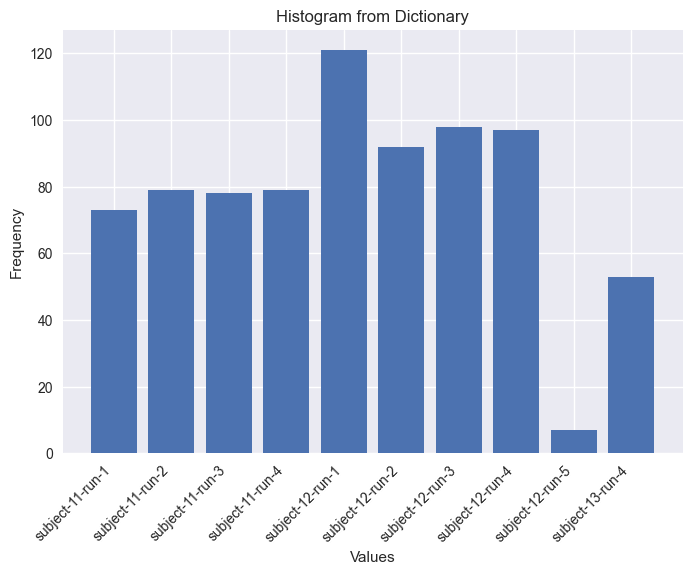

In [13]:
import matplotlib.pyplot as plt

nonzero = {}

for label, values in fucked.items():
    if values['fucked'] != 0:
        s = label.split("-")
        nonzero[f"subject-{s[0]}-run-{s[1]}"] = values['fucked']

plt.bar(nonzero.keys(), nonzero.values())
plt.xticks(
    ticks=range(len(nonzero)),
    labels=nonzero.keys(),
    rotation=45,       # Rotate labels if needed
    ha='right'         # Align labels to the right
)

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram from Dictionary')
plt.legend()